<a href="https://colab.research.google.com/github/Pankhuri33/SONG-GENRE-classification/blob/main/Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# Load Dataset
data_path = '/content/features_3_sec.csv'  # Path to your dataset
data = pd.read_csv(data_path)

In [3]:
# Display dataset information
print("Dataset Head:\n", data.head())
print("\nDataset Info:")
data.info()

Dataset Head:
             filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1  blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2  blues.00000.2.wav   66149          0.346815         0.092243  0.132003   
3  blues.00000.3.wav   66149          0.363639         0.086856  0.132565   
4  blues.00000.4.wav   66149          0.335579         0.088129  0.143289   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.003521             1773.065032          167541.630869   
1  0.001450             1816.693777           90525.690866   
2  0.004620             1788.539719          111407.437613   
3  0.002448             1655.289045          111952.284517   
4  0.001701             1630.656199           79667.267654   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              1972.744388           117335.771563  ...   39.687145   
1      

In [4]:
# Check for missing values
if data.isnull().sum().sum() > 0:
    print("\nMissing values detected. Handling them...")
    data = data.dropna()
else:
    print("\nNo missing values detected.")


No missing values detected.


In [9]:
# Extract features and labels
# Ensure only numerical columns are selected, excluding filenames or non-feature columns
X = data.drop(columns=['filename', 'label'], errors='ignore')  # Replace 'filename' and 'label' with actual column names
X = X.select_dtypes(include=[np.number])  # Only numerical columns

In [10]:
# Encode labels
y = data['label']  # Replace 'label' with the actual column containing genre names
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("\nEncoded Labels:", encoder.classes_)


Encoded Labels: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [11]:
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [12]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nTraining and testing data prepared.")


Training and testing data prepared.


In [13]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model training complete.")



Training the model...
Model training complete.


In [14]:
# Make predictions
y_pred = model.predict(X_test)

In [15]:
# Evaluate the model
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

       blues       0.83      0.88      0.85       200
   classical       0.92      0.96      0.94       199
     country       0.79      0.79      0.79       199
       disco       0.83      0.84      0.84       200
      hiphop       0.92      0.86      0.89       200
        jazz       0.85      0.89      0.87       200
       metal       0.86      0.94      0.90       200
         pop       0.94      0.82      0.88       200
      reggae       0.83      0.89      0.86       200
        rock       0.87      0.74      0.80       200

    accuracy                           0.86      1998
   macro avg       0.86      0.86      0.86      1998
weighted avg       0.86      0.86      0.86      1998


Confusion Matrix:
 [[175   1   5   1   0   5   7   0   5   1]
 [  0 191   1   0   0   5   0   0   0   2]
 [ 18   1 157   2   1   7   2   3   6   2]
 [  2   0   6 169   1   1   8   1   7   5]
 [  0   0   2   7 173   

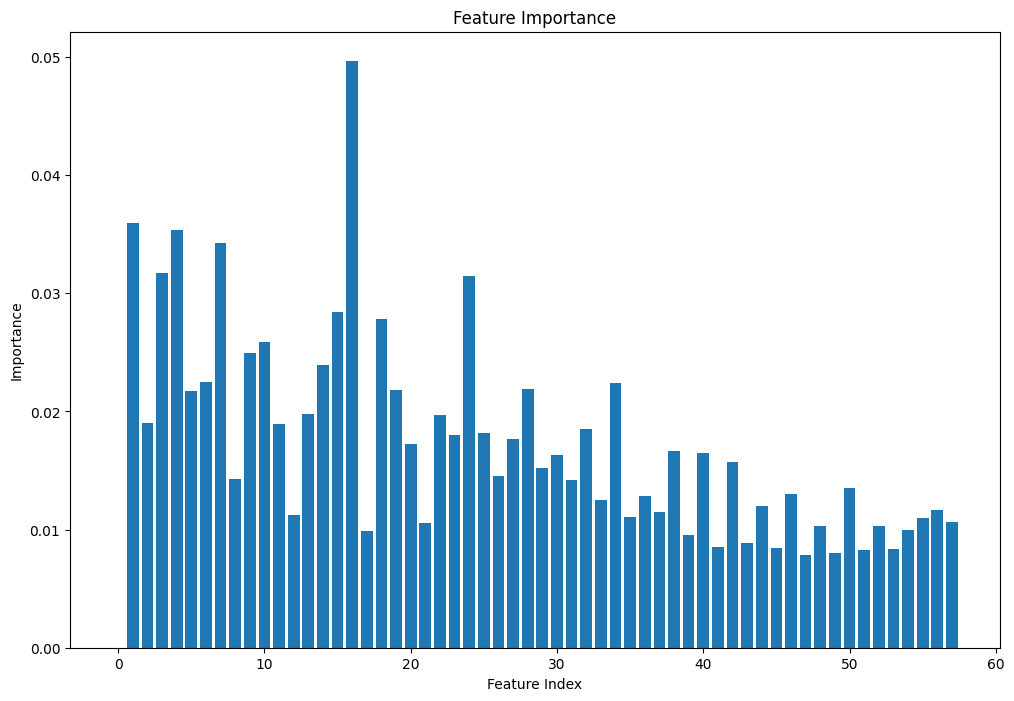

In [16]:
# Feature Importance Visualization
feature_importances = model.feature_importances_
plt.figure(figsize=(12, 8))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()


In [17]:
# Save the model (Optional)
import joblib
joblib.dump(model, 'genre_classifier_model.pkl')
print("\nModel saved as 'genre_classifier_model.pkl'.")


Model saved as 'genre_classifier_model.pkl'.


**WORKING ON 30-sec feature**s


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [25]:
# Load the 30-second features dataset
data_path = 'features_30_sec.csv'  # Replace with the actual path to your dataset
data = pd.read_csv(data_path)

In [26]:
# Display dataset information
print("Dataset Head:\n", data.head())
print("\nDataset Info:")
data.info()

Dataset Head:
           filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.wav  661794          0.350088         0.088757  0.130228   
1  blues.00001.wav  661794          0.340914         0.094980  0.095948   
2  blues.00002.wav  661794          0.363637         0.085275  0.175570   
3  blues.00003.wav  661794          0.404785         0.093999  0.141093   
4  blues.00004.wav  661794          0.308526         0.087841  0.091529   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.002827             1784.165850          129774.064525   
1  0.002373             1530.176679          375850.073649   
2  0.002746             1552.811865          156467.643368   
3  0.006346             1070.106615          184355.942417   
4  0.002303             1835.004266          343399.939274   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              2002.449060            85882.761315  ...   52.420910   
1              2039

In [27]:
# Check for missing values
if data.isnull().sum().sum() > 0:
    print("\nMissing values detected. Handling them...")
    data = data.dropna()
else:
    print("\nNo missing values detected.")


No missing values detected.


In [28]:
# Extract features and labels
# Ensure only numerical columns are selected, excluding filenames or non-feature columns
X = data.drop(columns=['filename', 'label'], errors='ignore')  # Replace 'filename' and 'label' with actual column names
X = X.select_dtypes(include=[np.number])  # Only numerical columns

In [29]:
# Encode labels
y = data['label']  # Replace 'label' with the actual column containing genre names
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("\nEncoded Labels:", encoder.classes_)


Encoded Labels: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [30]:
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [31]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nTraining and testing data prepared.")


Training and testing data prepared.


In [32]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model training complete.")


Training the model...
Model training complete.


In [33]:
# Make predictions
y_pred = model.predict(X_test)

In [34]:
# Evaluate the model
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

       blues       0.79      0.75      0.77        20
   classical       0.86      0.95      0.90        20
     country       0.71      0.75      0.73        20
       disco       0.71      0.60      0.65        20
      hiphop       0.65      0.75      0.70        20
        jazz       0.77      0.85      0.81        20
       metal       0.89      0.85      0.87        20
         pop       0.86      0.90      0.88        20
      reggae       0.76      0.80      0.78        20
        rock       0.73      0.55      0.63        20

    accuracy                           0.78       200
   macro avg       0.77      0.78      0.77       200
weighted avg       0.77      0.78      0.77       200


Confusion Matrix:
 [[15  0  2  0  0  0  0  0  2  1]
 [ 0 19  0  0  0  1  0  0  0  0]
 [ 0  0 15  0  0  2  0  0  1  2]
 [ 0  1  1 12  5  0  1  0  0  0]
 [ 1  0  0  2 15  0  1  0  0  1]
 [ 1  2  0  0  0 17  0  0  0  0

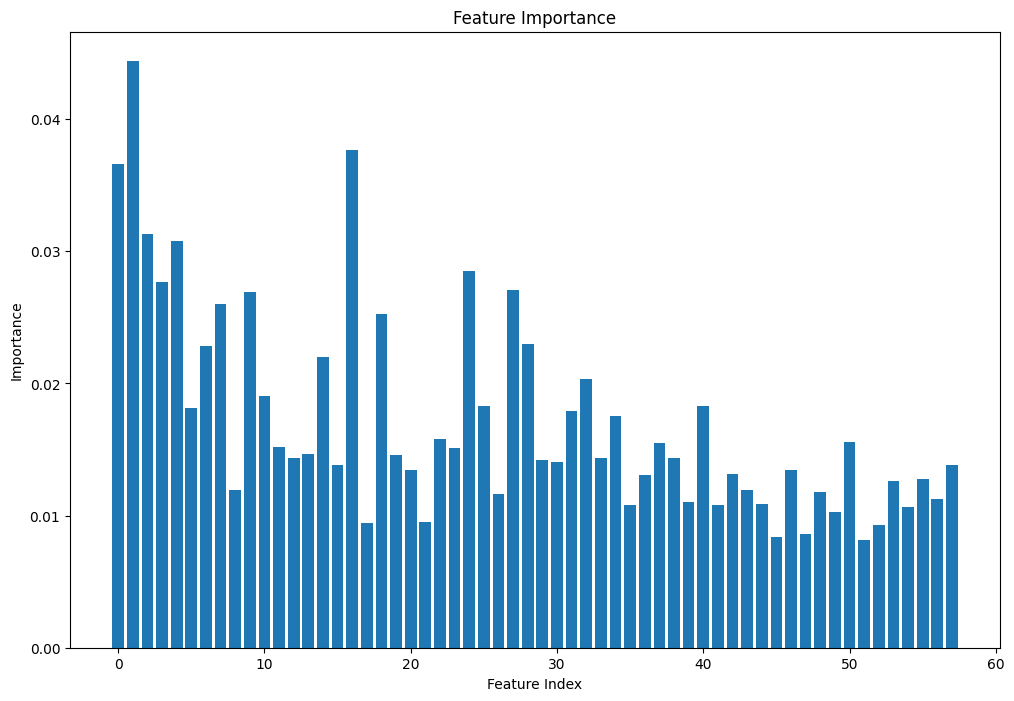

In [35]:
# Feature Importance Visualization
import matplotlib.pyplot as plt
feature_importances = model.feature_importances_
plt.figure(figsize=(12, 8))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [36]:
# Save the model (Optional)
import joblib
joblib.dump(model, 'genre_classifier_model.pkl')
print("\nModel saved as 'genre_classifier_model.pkl'.")


Model saved as 'genre_classifier_model.pkl'.


In the context of song genre classification, the difference between 3-second features and 30-second features generally refers to the duration of the audio window from which features (such as spectral features like MFCCs, chroma, or spectrograms) are extracted for classification.

3-second features:


Features are extracted from smaller chunks of the song, focusing on a short duration (3 seconds).
These smaller windows capture more granular, localized information, allowing the model to focus on more specific patterns or changes in the music.
It may be useful for detecting fast-changing elements in the music, such as tempo or sharp changes in dynamics.
However, this might also lead to a higher variability or noise in the feature extraction process, as short snippets may not capture the full essence of the genre.
30-second features:



Features are extracted from longer audio segments (30 seconds).
These windows provide a broader context of the song, allowing the model to capture the overall structure, rhythm, melody, and harmony of the music.
The longer duration may help the model recognize more complex patterns and contextual features that are important for genre classification.
However, it may also lose some of the finer details, especially for fast or rapidly changing genres.
In a visualization, you might see the following differences:

3-second features: More fluctuation or finer details in the features, reflecting the rapid changes in music elements.




30-second features: More stable or averaged-out features, providing a smoother representation of the song's overall characteristics.
Choosing between 3-second and 30-second features depends on the nature of the music and the classification task. Shorter windows are good for detecting fast changes, while longer windows are better for capturing the broader patterns in the music.